In [1]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\Vinay\anaconda\envs\oncovision\python.exe
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

columns = [
    "id", "diagnosis",

    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

print("Columns:", len(columns))

@ data loading

In [4]:
df = pd.read_csv(
    "../data/raw/breast/wdbc.data",
    header=None,
    names=columns
)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [9]:
missing = df.isnull().sum()
missing




id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [13]:
df["target"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

df[["diagnosis", "target"]].head()

,diagnosis,target
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


In [14]:
df.groupby("diagnosis").mean(numeric_only=True).T

diagnosis,B,M
id,2.654382e+07,3.681805e+07
radius_mean,1.214652e+01,1.746283e+01
texture_mean,1.791476e+01,2.160491e+01
perimeter_mean,7.807541e+01,1.153654e+02
area_mean,4.627902e+02,9.783764e+02
smoothness_mean,9.247765e-02,1.028985e-01
compactness_mean,8.008462e-02,1.451878e-01
concavity_mean,4.605762e-02,1.607747e-01
concave_points_mean,2.571741e-02,8.799000e-02
symmetry_mean,1.741860e-01,1.929090e-01


In [15]:
features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

df.groupby("diagnosis")[features].mean()

,radius_mean,texture_mean,perimeter_mean,area_mean
diagnosis,,,,
B,12.146524,17.914762,78.075406,462.790196
M,17.462830,21.604906,115.365377,978.376415


## analysis

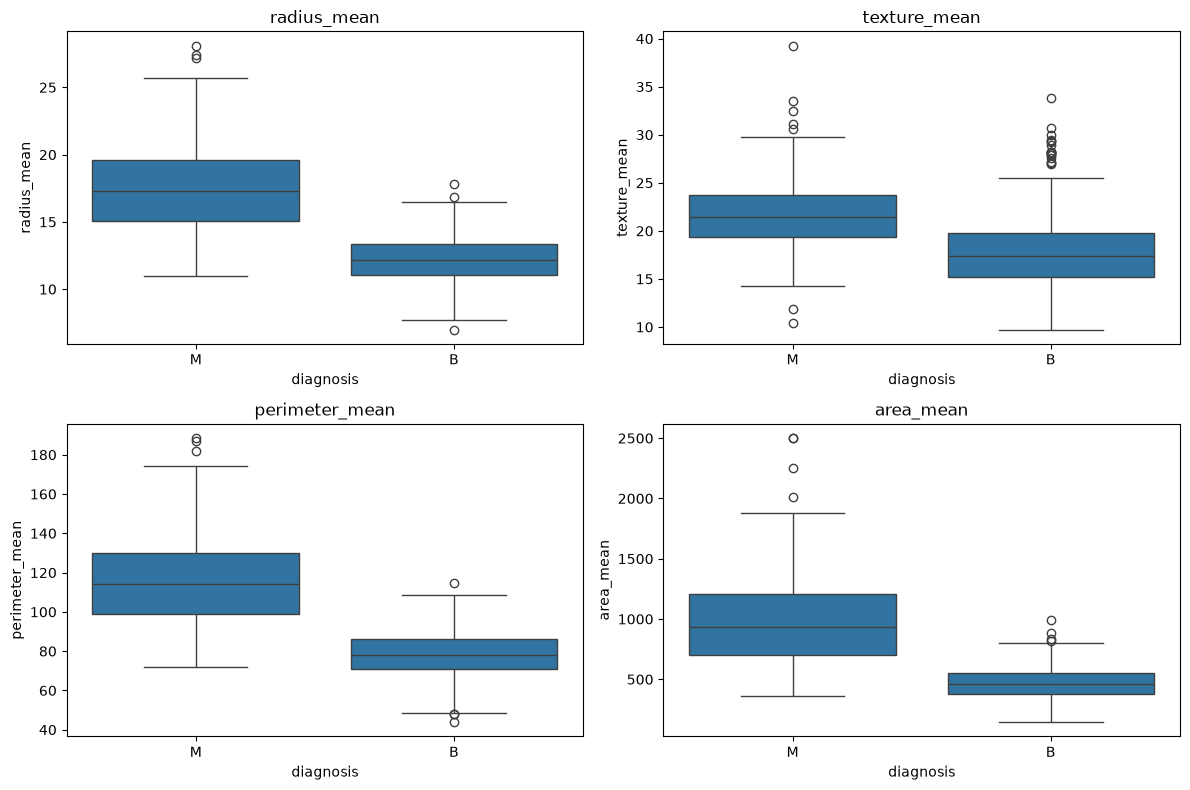

In [17]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="diagnosis", y=feature)
    plt.title(feature)

plt.tight_layout()
plt.show()

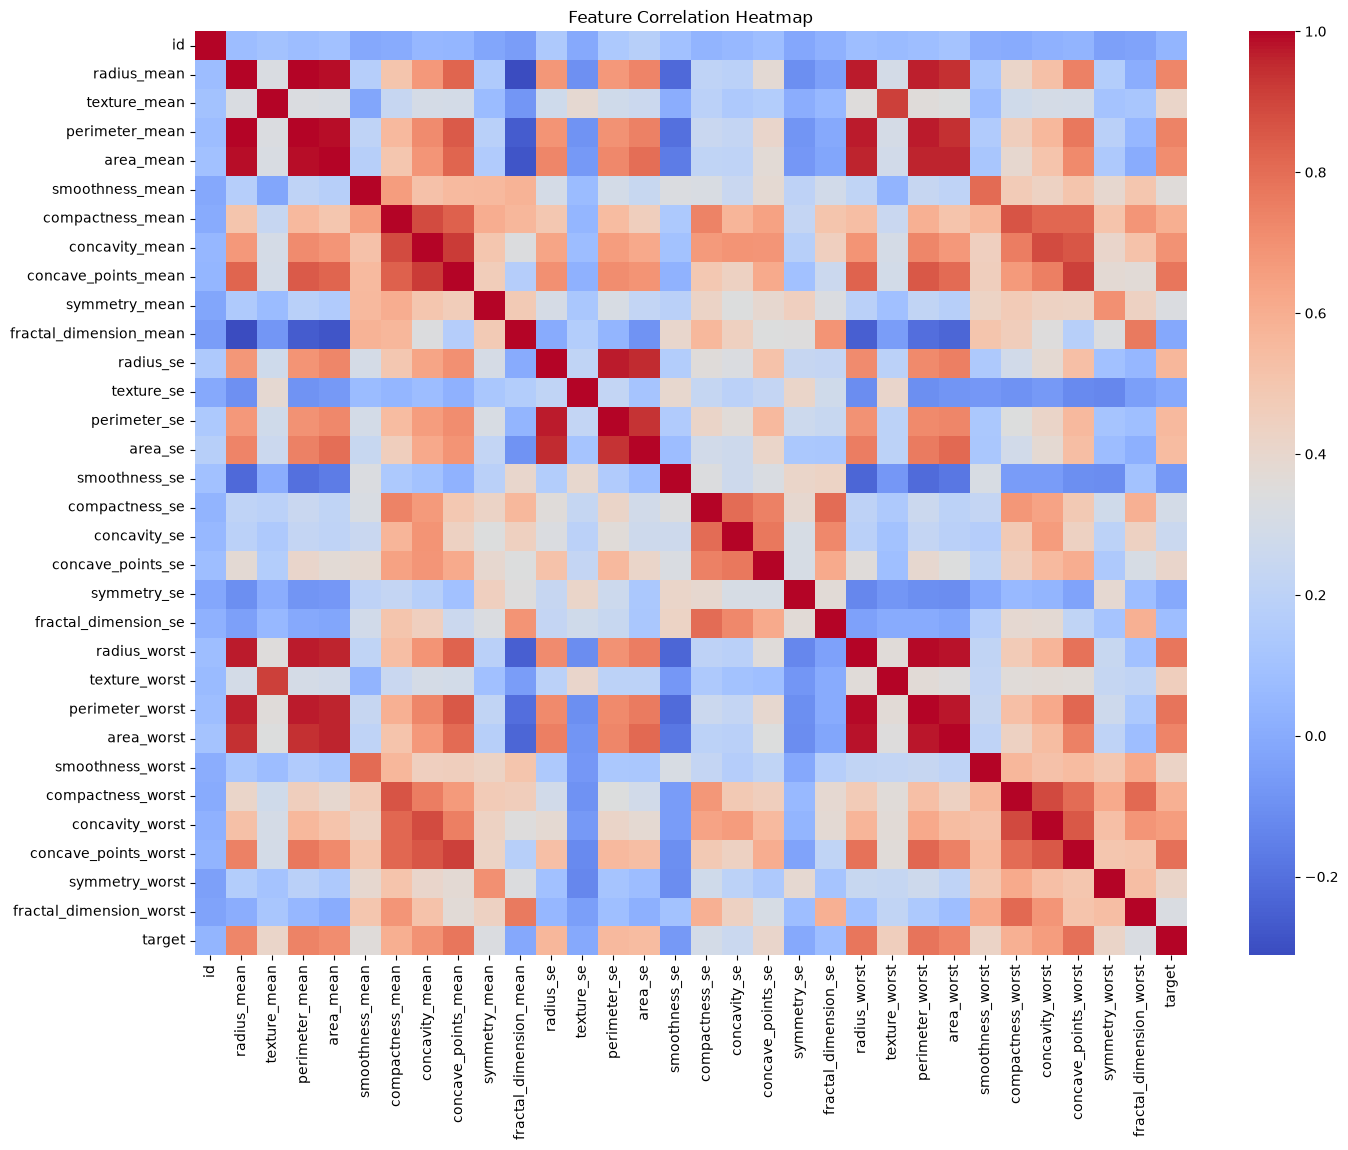

In [18]:
plt.figure(figsize=(16, 12))

corr = df.drop(columns=["diagnosis"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
target_corr = (
    df.drop(columns="diagnosis")
      .corr()["target"]
      .drop("target")
      .sort_values(key=abs, ascending=False)
)

target_corr

concave_points_worst       0.793566
perimeter_worst            0.782914
concave_points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave_points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
smoothness_se             -0.067016
id                         0

In [20]:
top_features = target_corr.abs().head(10)

print("Top 10 features:")
print(top_features)

Top 10 features:
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: target, dtype: float64


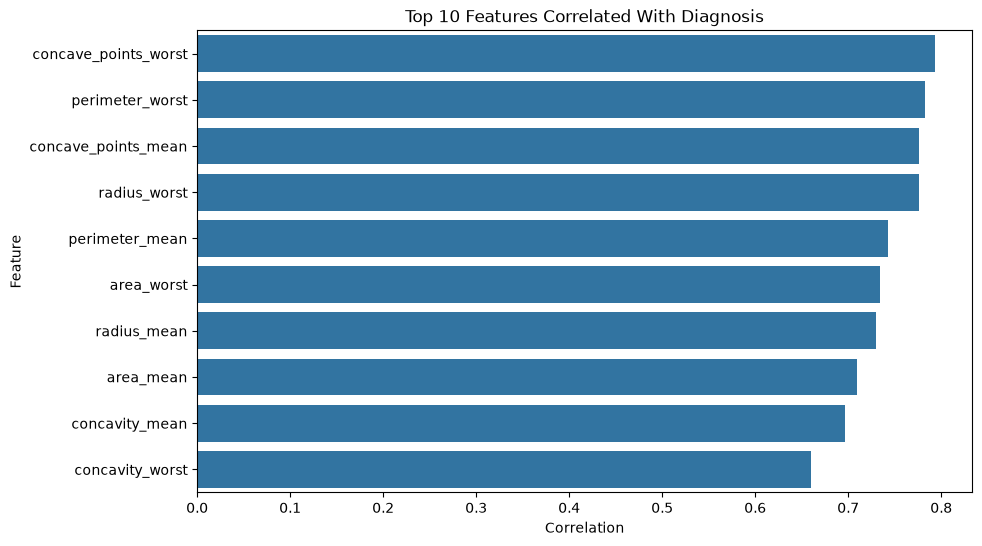

In [21]:
top10 = top_features.index

plt.figure(figsize=(10, 6))

sns.barplot(
    x=target_corr[top10].values,
    y=top10
)

plt.title("Top 10 Features Correlated With Diagnosis")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [22]:
feature_corr = df.drop(columns=["diagnosis", "target"]).corr()

high_corr = []

for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) >= 0.90:
            high_corr.append([
                feature_corr.index[i],
                feature_corr.columns[j],
                feature_corr.iloc[i, j]
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df.sort_values(
    by="Correlation",
    key=abs,
    ascending=False
).head(20)

,Feature 1,Feature 2,Correlation
0,radius_mean,perimeter_mean,0.997855
18,radius_worst,perimeter_worst,0.993708
1,radius_mean,area_mean,0.987357
6,perimeter_mean,area_mean,0.986507
19,radius_worst,area_worst,0.984015
20,perimeter_worst,area_worst,0.977578
15,radius_se,perimeter_se,0.972794
8,perimeter_mean,perimeter_worst,0.970387
2,radius_mean,radius_worst,0.969539
7,perimeter_mean,radius_worst,0.969476


In [25]:
feature_corr = df.drop(columns=["diagnosis", "target"]).corr()

high_corr = []

for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) >= 0.90:
            high_corr.append([
                feature_corr.index[i],
                feature_corr.columns[j],
                feature_corr.iloc[i, j]
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df.sort_values(
    by="Correlation",
    key=abs,
    ascending=False
).head(20)

,Feature 1,Feature 2,Correlation
0,radius_mean,perimeter_mean,0.997855
18,radius_worst,perimeter_worst,0.993708
1,radius_mean,area_mean,0.987357
6,perimeter_mean,area_mean,0.986507
19,radius_worst,area_worst,0.984015
20,perimeter_worst,area_worst,0.977578
15,radius_se,perimeter_se,0.972794
8,perimeter_mean,perimeter_worst,0.970387
2,radius_mean,radius_worst,0.969539
7,perimeter_mean,radius_worst,0.969476


In [26]:
numeric_features = df.drop(
    columns=["id", "diagnosis", "target"]
)

outlier_counts = {}

for column in numeric_features.columns:
    Q1 = numeric_features[column].quantile(0.25)
    Q3 = numeric_features[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (numeric_features[column] < lower) |
        (numeric_features[column] > upper)
    ).sum()

    outlier_counts[column] = count

outliers = pd.Series(outlier_counts).sort_values(
    ascending=False
)

outliers.head(15)

area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
symmetry_worst             23
concavity_se               22
texture_se                 20
concave_points_se          19
concavity_mean             18
dtype: int64

In [27]:
X = df.drop(columns=["id", "diagnosis", "target"])
y = df["target"]

print("Features:", X.shape[1])
print("Samples:", X.shape[0])

Features: 30
Samples: 569


In [28]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly correlated features:")
print(high_corr_features)
print("\nNumber:", len(high_corr_features))

Highly correlated features:
['perimeter_mean', 'area_mean', 'concave_points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave_points_worst']

Number: 10


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

perimeter_worst         0.143121
area_worst              0.142449
concave_points_worst    0.112978
concave_points_mean     0.088663
radius_worst            0.082649
radius_mean             0.061043
perimeter_mean          0.052928
area_mean               0.043820
concavity_mean          0.039761
area_se                 0.032237
concavity_worst         0.031598
compactness_mean        0.017313
texture_worst           0.017121
compactness_worst       0.015661
smoothness_worst        0.013990
dtype: float64

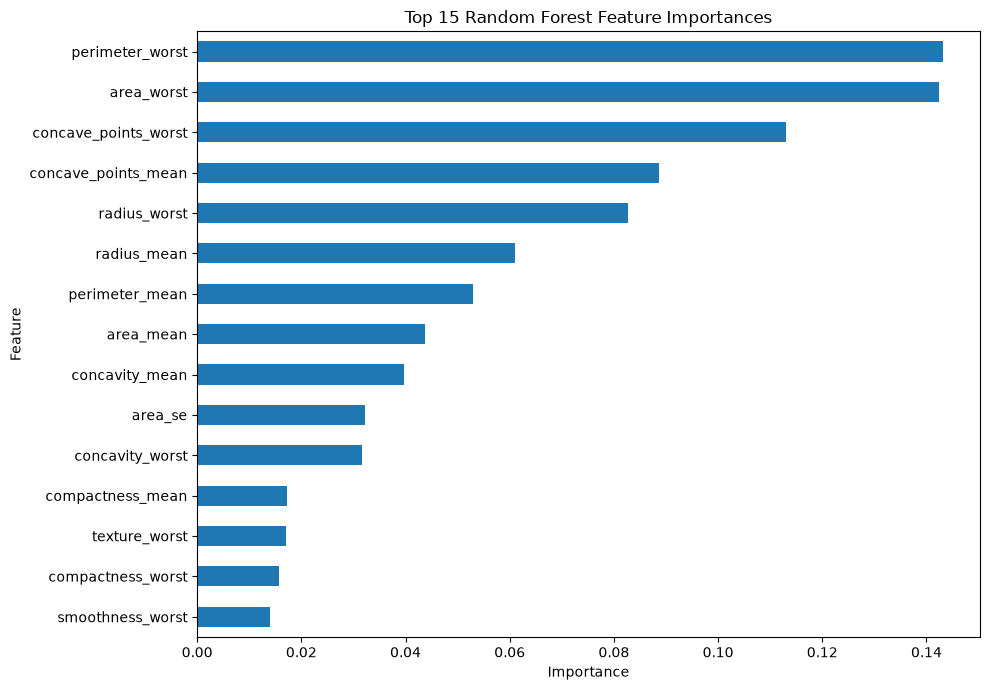

In [30]:
plt.figure(figsize=(10, 7))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()